In [205]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [206]:
# fixing all the columns as of now
# Fix EDUCATION (5 and 6 are officially "unknown", 0 is undocumented)
edu_map = {
    1: "Graduate",
    2: "University",
    3: "HighSchool",
    4: "Other",
    5: "Other",
    6: "Other",
    0: "Other",
}
df["EDUCATION"] = df["EDUCATION"].map(edu_map)

# Verify
# print(df["EDUCATION"].value_counts())
# print("NaNs:", df["EDUCATION"].isnull().sum())


marital_map = {
    1: "Married",
    2: "Single",
    3: "Other",
    0: "Other", 
}
df["MARRIAGE"] = df["MARRIAGE"].map(marital_map)


sex_map = {
    1: "Male", 
    2: "Female"
    }
df["SEX"] = df["SEX"].map(sex_map)

# Verify
# print(df["SEX"].value_counts())
# print("NaNs:", df["SEX"].isnull().sum())

# Dropping the ID and Renaming the last column
# df.drop('ID', axis=1, inplace=True)

df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,Female,University,Married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,Female,University,Single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,Female,University,Single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,Female,University,Married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,Male,University,Married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,Male,HighSchool,Married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,Male,HighSchool,Single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,Male,University,Single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,Male,HighSchool,Married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [207]:
# Utilization
df["utilization"] = df["BILL_AMT1"] / (df["LIMIT_BAL"] + 1)
# print(df["utilization"].describe().round(3))


# Payment Ratio Calculation
bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
]
pay_cols = [
    "PAY_AMT1", 
    "PAY_AMT2", 
    "PAY_AMT3", 
    "PAY_AMT4", 
    "PAY_AMT5", 
    "PAY_AMT6"
    ]

bill_total = df[bill_cols].sum(axis=1).replace(0, np.nan)
pay_total = df[pay_cols].sum(axis=1)

df["payment_ratio"] = (pay_total / bill_total).clip(0, 1)


pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df["late_months"] = (df[pay_status_cols] > 0).sum(axis=1)

print(df["late_months"].value_counts().sort_index())


df["bill_trend"] = df["BILL_AMT1"] - df["BILL_AMT6"]

df.rename(columns={"default.payment.next.month": "default"}, inplace=True)

late_months
0    19931
1     4426
2     1899
3     1154
4      951
5      298
6     1341
Name: count, dtype: int64


In [208]:
df.rename(columns={"default.payment.next.month": "default"}, inplace=True)
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default', 'utilization', 'payment_ratio', 'late_months', 'bill_trend']


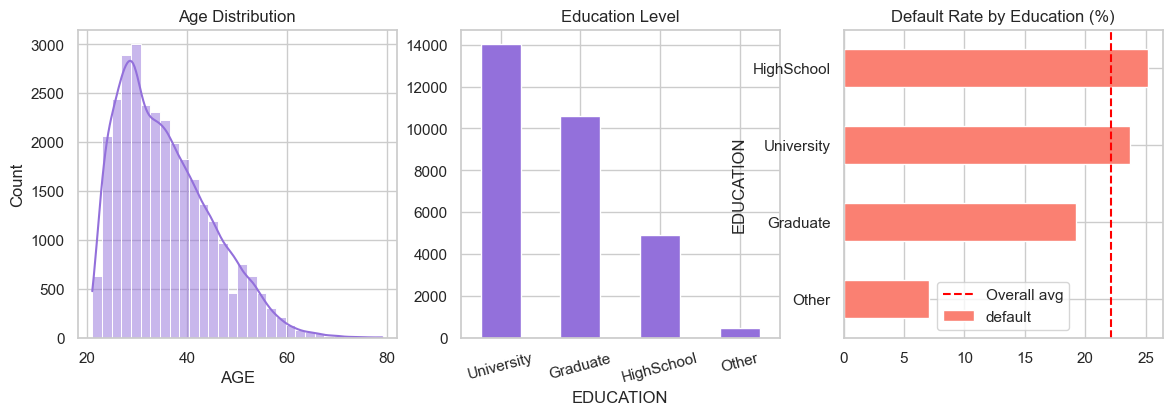

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age distribution
sns.histplot(df["AGE"], bins=30, kde=True, ax=axes[0], color="mediumpurple")
axes[0].set_title("Age Distribution")

# Education breakdown
df["EDUCATION"].value_counts().plot(
    kind="bar", ax=axes[1], color="mediumpurple", edgecolor="white"
)
axes[1].set_title("Education Level")
axes[1].tick_params(axis="x", rotation=15)

# Default rate by education
default_by_edu = df.groupby("EDUCATION")["default"].mean() * 100
default_by_edu.sort_values().plot(
    kind="barh", ax=axes[2], color="salmon", edgecolor="white"
)
axes[2].set_title("Default Rate by Education (%)")
axes[2].axvline(
    df["default"].mean() * 100, color="red", linestyle="--", label="Overall avg"
)
axes[2].legend()


plt.show()

/var/folders/c0/hkqjbl8n1b359xf20y52j6q00000gn/T/ipykernel_9750/2029481636.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/c0/hkqjbl8n1b359xf20y52j6q00000gn/T/ipykernel_9750/2029481636.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dr = df.groupby("limit_group")["default"].mean() * 100


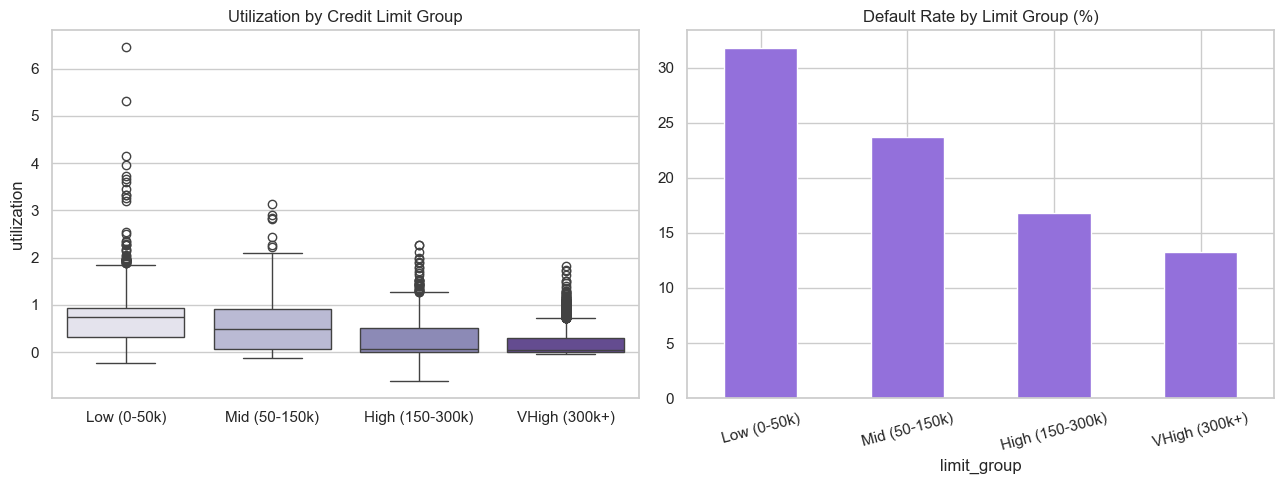

In [210]:
df["limit_group"] = pd.cut(
    df["LIMIT_BAL"],
    bins=[0, 50000, 150000, 300000, 1000000],
    labels=["Low (0-50k)", "Mid (50-150k)", "High (150-300k)", "VHigh (300k+)"],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=df,
    x="limit_group",
    y="utilization",
    ax=axes[0],
    palette="Purples",
    order=["Low (0-50k)", "Mid (50-150k)", "High (150-300k)", "VHigh (300k+)"],
)
axes[0].set_title("Utilization by Credit Limit Group")
axes[0].set_xlabel("")

dr = df.groupby("limit_group")["default"].mean() * 100
dr.plot(kind="bar", ax=axes[1], color="mediumpurple", edgecolor="white")
axes[1].set_title("Default Rate by Limit Group (%)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("02_limit_utilization.png", dpi=150)
plt.show()

In [211]:
from scipy import stats

df["util_zscore"] = df.groupby("EDUCATION")["utilization"].transform(
    lambda x: stats.zscore(x, nan_policy="omit")
)

df["stress_spender"] = df["util_zscore"] > 2.0

print(
    f"Stress spenders: {df['stress_spender'].sum()} ({df['stress_spender'].mean()*100:.1f}%)"
)
print(
    "Default rate - stress spenders:",
    df[df["stress_spender"]]["default"].mean().round(3),
)
print("Default rate - normal:", df[~df["stress_spender"]]["default"].mean().round(3))

Stress spenders: 326 (1.1%)
Default rate - stress spenders: 0.264
Default rate - normal: 0.221
